# Grid Parameter Comparison Dashboard

Compare **synthetic grids** (generated by pylovo) with **real grids** (measured field data) across six comparison metrics:
`feeder_lines`, `graph_length`, `avg_trafo_distance`, `max_trafo_distance`, `transformer_mva`, `graph_resistance`.

## Notebook Structure

| Section | Content |
|---|---|
| **0. Configure** | Define metrics, labels, real-grid path, and the explicit synthetic power-flow status filter |
| **1. Load Data** | Load synthetic metrics from CSV / DB, inspect status counts, and build the filtered comparison dataset |
| **2. Structural Comparison** | Box plots per metric — quick visual comparison of location and spread |
| **3. Violin Plots** | Split violin plots — full distribution shape side by side |
| **3. Statistical Analysis** | Summary statistics table, ECDF, radar chart, seaborn pairplot |
| **4. Geospatial Comparison** | Interactive map view of individual real and synthetic grids |

 > **Requirements:** Sections 1–3 need only the CSV files in `validation/metrics/`.  
 > Synthetic metrics use `synthetic_grid_metrics.csv`; the notebook applies the chosen `SYNTHETIC_STATUS_FILTER` explicitly instead of silently dropping non-converged grids.  
 > Section 4 (geospatial) additionally requires a database connection (synthetic) and `REAL_GRID_DIR` configured below (real grids).


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = (project_root / ".." / "..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import scipy.stats as stats
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, interactive, fixed

import pandapower as pp
import pandapower.plotting.plotly as pp_plotly

from pylovo.database.database_client import DatabaseClient
from pylovo.analysis.comparison_helpers import compute_wasserstein_summary
from pylovo.plotting.validation.metric_validation import (
    plot_comparison_distribution_plotly,
    plot_hist_trafos
)
from validation.grid_comparison.comparison_notebook import (
    plot_boxplot_overview,
    plot_metric_kde_diagonal,
    show_cable_type_comparison,
    show_wasserstein_summary,
)

# Set Plotly Template
import plotly.io as pio
pio.templates.default = "plotly_white"


## 0. Configure Data Selection

In [2]:
metrics = [
    "feeder_lines",
    "buildings_per_feeder",
    "graph_length",
    "avg_trafo_distance",
    "max_trafo_distance",
    "transformer_mva",
    "graph_resistance",
]

labels = {
    "feeder_lines": "Number of Feeder Lines (count)",
    "buildings_per_feeder": "Buildings per Feeder",
    "graph_length": "Graph Length (km)",
    "avg_trafo_distance": "Avg. Distance to Trafo (km)",
    "max_trafo_distance": "Max. Distance to Trafo (km)",
    "transformer_mva": "Transformer Rating (MVA)",
    "graph_resistance": "Graph Resistance Proxy (Ohm)",
}

# Explicitly choose which synthetic power-flow statuses should enter the comparison.
# Use ["converged"] for legacy behavior, or None to keep all available statuses.
SYNTHETIC_STATUS_FILTER = ["converged", "voltage_violation", "not_converged"]

# Path to the directory containing real grid files (e.g. LV_*.json or LV_*.xlsx).
# Set this to the folder where your pandapower-exported real grids are stored.
REAL_GRID_DIR = Path("/home/breveron/data/regular_nets")
# REAL_GRID_DIR: Path | None = None
PLZ = 91301

## 1. Load Data

In [18]:
# 1. Load Synthetic and Real Data from CSV if available, else fall back to DB for synthetic data
def resolve_metrics_path(filename: str) -> Path | None:
    candidates = [
        Path("validation") / "metrics" / filename,
        Path("metrics") / filename,
        Path("..") / "validation" / "metrics" / filename,
        Path("..") / "metrics" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


synth_metrics_path = resolve_metrics_path("synthetic_grid_metrics.csv")

if synth_metrics_path is not None:
    df_synth_all = pd.read_csv(synth_metrics_path)
    print(f"Loaded {len(df_synth_all)} synthetic grids from CSV: {synth_metrics_path}")
else:
    try:
        with DatabaseClient() as dbc:
            query = "SELECT * FROM grid_parameters"
            df_synth_all = pd.read_sql(query, dbc.sqla_engine)
            print(f"Loaded {len(df_synth_all)} synthetic grids from DB.")
    except Exception as e:
        print(f"Error loading synthetic data: {e}")
        df_synth_all = pd.DataFrame()

if not df_synth_all.empty and "power_flow_status" not in df_synth_all.columns:
    df_synth_all["power_flow_status"] = "converged"

if not df_synth_all.empty:
    available_statuses = sorted(df_synth_all["power_flow_status"].dropna().unique().tolist())
    status_counts = (
        df_synth_all["power_flow_status"]
        .fillna("unknown")
        .value_counts()
        .rename_axis("power_flow_status")
        .reset_index(name="count")
    )
    print("\nSynthetic grid status counts:")
    display(status_counts)

    if SYNTHETIC_STATUS_FILTER is None:
        selected_statuses = available_statuses
    else:
        selected_statuses = [
            status for status in SYNTHETIC_STATUS_FILTER if status in set(available_statuses)
        ]
        if not selected_statuses:
            raise ValueError(
                f"SYNTHETIC_STATUS_FILTER={SYNTHETIC_STATUS_FILTER} does not match available statuses {available_statuses}."
            )

    df_synth = df_synth_all[
        df_synth_all["power_flow_status"].isin(selected_statuses)
    ].copy()
    print(
        f"Using {len(df_synth)} synthetic grids after applying status filter: {selected_statuses}"
    )
else:
    df_synth = pd.DataFrame()

df_synth["Type"] = "Synthetic"

real_csv_path = resolve_metrics_path("real_grid_metrics.csv")
if real_csv_path is not None:
    df_real = pd.read_csv(real_csv_path)
    df_real["Type"] = "Real"
    print(f"Loaded {len(df_real)} real grids from CSV: {real_csv_path}")
else:
    print("Real grid metrics CSV not found.")
    df_real = pd.DataFrame()
    df_real["Type"] = pd.Series(dtype="object")

df_all = pd.concat([df_synth, df_real], ignore_index=True, sort=False)

if not df_all.empty:
    # Align 'Type' with the library plotting API which expects a 'source' column
    df_all["source"] = df_all["Type"]
    print(f"\nCombined dataset: {len(df_all)} grids total")
    display(df_all.head())
else:
    print("Combined dataset is empty.")

Loaded 171 synthetic grids from CSV: ../metrics/synthetic_grid_metrics.csv

Synthetic grid status counts:


,power_flow_status,count
0,converged,113
1,voltage_violation,58


Using 171 synthetic grids after applying status filter: ['converged', 'voltage_violation']
Loaded 138 real grids from CSV: ../metrics/real_grid_metrics.csv

Combined dataset: 309 grids total


,feeder_lines,buildings_per_feeder,graph_length,avg_trafo_distance,max_trafo_distance,transformer_mva,graph_resistance,power_flow_status,grid_result_id,kcid,bcid,Type,grid_name,file_name,source
0,7,12.142857,3.788267,0.361308,0.626090,0.63,1.307619,voltage_violation,2401.0,1.0,-3.0,Synthetic,NaN,NaN,Synthetic
1,20,10.350000,7.329526,0.315523,0.550384,0.63,2.769534,voltage_violation,2400.0,1.0,-2.0,Synthetic,NaN,NaN,Synthetic
2,12,13.083333,5.703994,0.240623,0.364953,0.63,2.382456,voltage_violation,2399.0,1.0,-1.0,Synthetic,NaN,NaN,Synthetic
3,14,9.642857,5.833791,0.232052,0.556927,0.63,2.148779,voltage_violation,2402.0,1.0,1.0,Synthetic,NaN,NaN,Synthetic
4,13,6.846154,3.706734,0.179677,0.534804,0.63,1.375069,voltage_violation,2403.0,1.0,2.0,Synthetic,NaN,NaN,Synthetic


## 2. Box Plot Comparison

Box plots provide a quick overview of **location** (median line), **spread** (IQR box), **range** (whiskers), and **outliers** (individual points) for each metric. Use the dropdown to compare Synthetic vs. Real grids metric by metric.

> Rendered via `plot_comparison_distribution_plotly` from `pylovo.plotting.validation.metric_validation`.


In [86]:
def plot_box(metric):
    fig = plot_comparison_distribution_plotly(
        df_all,
        metric_col=metric,
        title=f"Box Plot: {labels.get(metric, metric)}",
        plot_type="box",
    )
    fig.update_yaxes(title_text=labels.get(metric, metric))
    fig.update_layout(height=520)
    fig.show()


interact(plot_box, metric=widgets.Dropdown(options=metrics, description="Parameter:"));


interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'graph_length', 'avg_trafo_d…

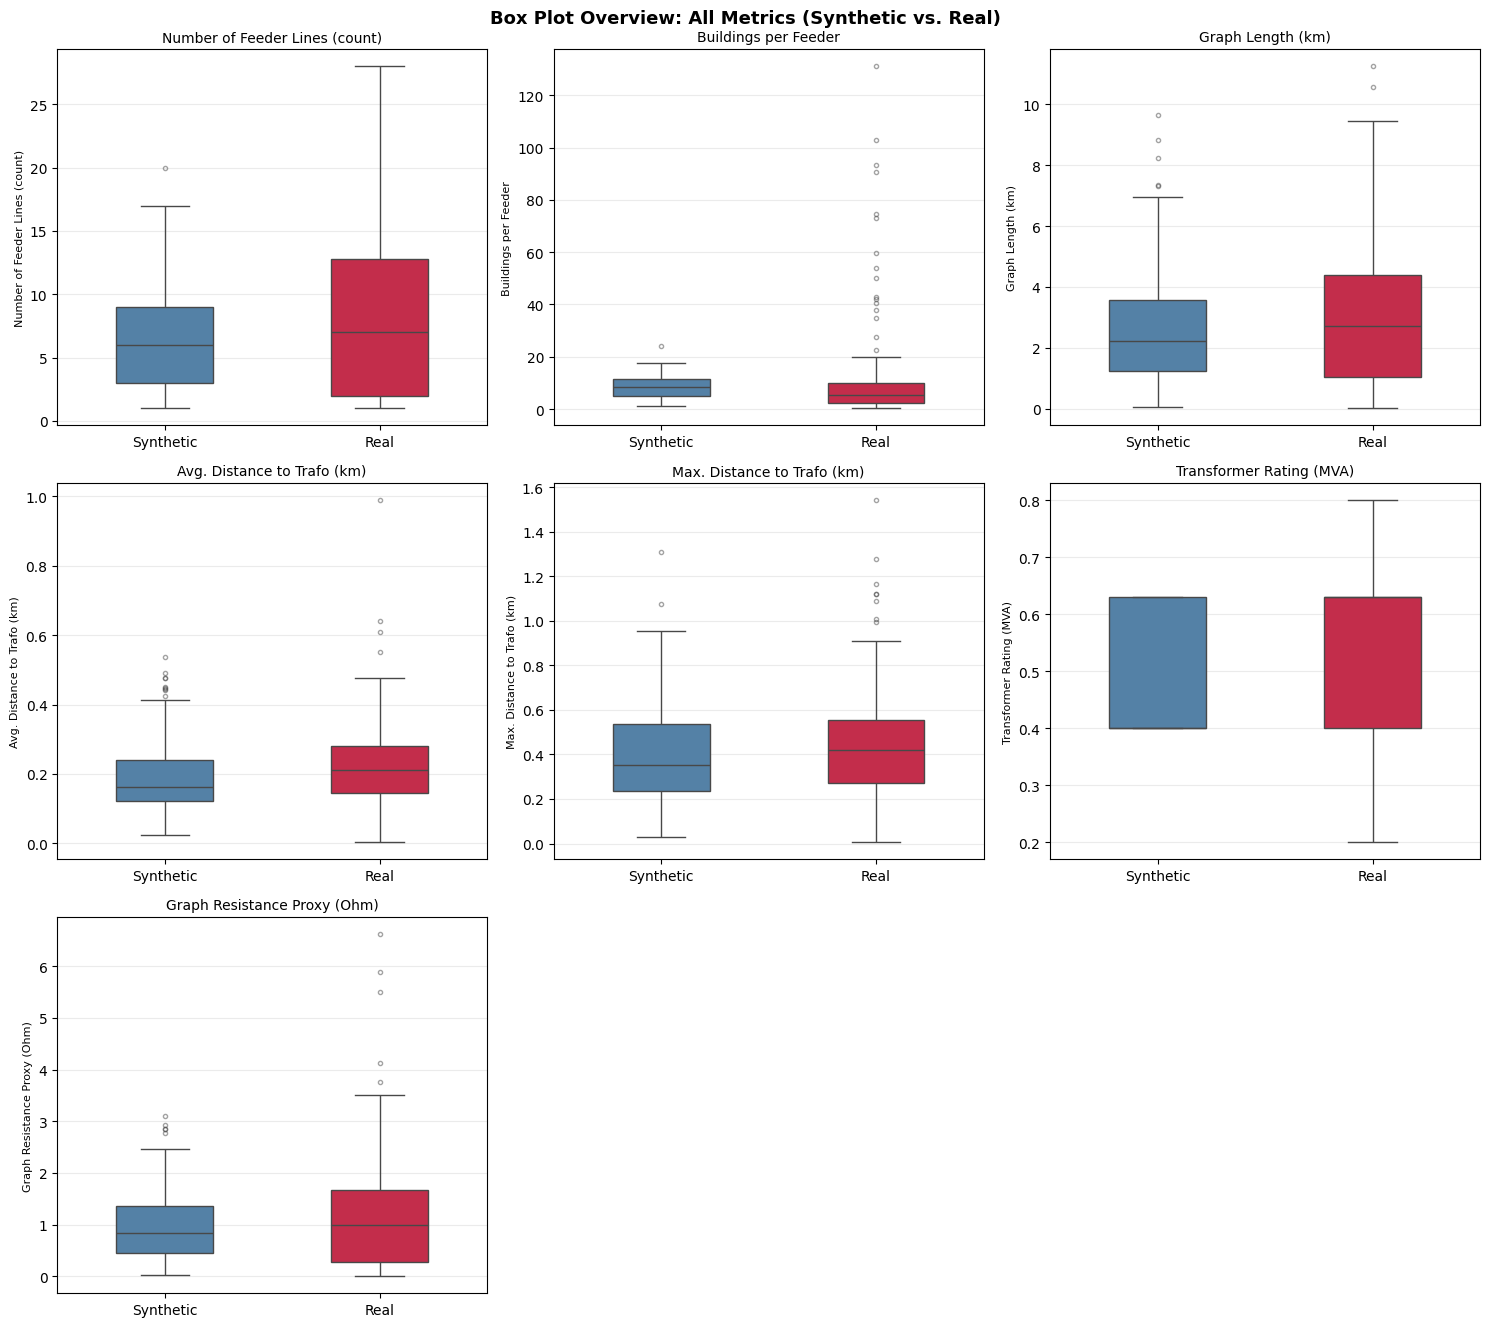

In [4]:
_ = plot_boxplot_overview(
    df_all,
    metrics,
    labels=labels,
    title="Box Plot Overview: All Metrics (Synthetic vs. Real)",
)

## 3. Violin Plot Comparison

Violin plots show the **full shape of the distribution** — not just the box statistics. The width of the shape encodes data density at each value. Inner boxes show IQR and median; individual data points are overlaid as a strip plot.

> Both sources are displayed side by side for direct visual comparison. Rendered via `plot_comparison_distribution_plotly` with `plot_type='violin'`.


In [ ]:
def plot_violin(metric):
    fig = plot_comparison_distribution_plotly(
        df_all,
        metric_col=metric,
        title=f"Violin: {labels.get(metric, metric)}",
        plot_type="violin",
    )
    fig.update_yaxes(title_text=labels.get(metric, metric))
    fig.update_layout(height=550, width=600)
    fig.show()


interact(plot_violin, metric=widgets.Dropdown(options=metrics, description="Parameter:"));


interactive(children=(Dropdown(description='Parameter:', options=('feeder_lines', 'graph_length', 'avg_trafo_d…

## 4. Statistical Analysis

Deeper quantitative comparison beyond visual inspection. This section addresses:
- **How different are the distributions really?** → Summary statistics table + ECDF
- **Are Synthetic grids systematically biased across all metrics?** → Radar chart (normalised medians)
- **Do inter-metric correlations match between sources?** → Seaborn pairplot

No additional dependencies beyond `scipy` and `seaborn` (both standard data-science packages).


### 4a. Summary Statistics Table

`describe()` for each metric, grouped by source. Gives a precise numerical picture of count, mean, std, min/max, and quartiles at a glance.


In [89]:
# print("=== Descriptive Statistics per Grid Source ===\n")
# summary = df_all.groupby('source')[metrics].describe().T

# with pd.option_context('display.float_format', '{:.3f}'.format, 'display.max_columns', None):
#     display(summary)


### 4b. ECDF — Empirical Cumulative Distribution Function

The ECDF is **model-free** and shows the true cumulative probability for every observed value. It is especially robust when the real-grid sample is small (no binning artefacts like histograms). The marginal histogram on top shows the raw count distribution.

Reading: if the Synthetic curve lies **left** of Real for a given probability, it means synthetic grids tend to have **smaller** values for that metric.


In [90]:
# def plot_ecdf(metric):
#     fig = px.ecdf(
#         df_all.dropna(subset=[metric]),
#         x=metric,
#         color='source',
#         color_discrete_map={'Synthetic': '#1f77b4', 'Real': '#d62728'},
#         title=f"ECDF: {labels.get(metric, metric)}",
#         labels={'source': 'Grid Source', metric: labels.get(metric, metric)},
#         marginal='histogram',
#         template='plotly_white',
#     )
#     fig.update_layout(height=520)
#     fig.show()


# interact(plot_ecdf, metric=widgets.Dropdown(options=metrics, description="Parameter:"));


### 4c. Radar Chart — Multi-metric Overview

A single-glance view across **all six metrics simultaneously**. Each axis shows the **normalised median** (0 = combined minimum, 1 = combined maximum) so metrics with different units are directly comparable. The filled area indicates how a source "fills" the metric space relative to the other.

> A Synthetic trace that consistently extends **beyond** the Real trace indicates systematic over-estimation; consistently **inside** indicates under-estimation.


In [91]:
# # Compute normalised median per source across all metrics
# radar_rows = {}
# for source in df_all['source'].dropna().unique():
#     subset = df_all[df_all['source'] == source]
#     radar_rows[source] = subset[metrics].median()

# df_radar = pd.DataFrame(radar_rows).T  # shape: (n_sources, n_metrics)

# # Normalise columns using combined min/max so all axes span [0, 1]
# col_min = df_all[metrics].min()
# col_max = df_all[metrics].max()
# col_range = (col_max - col_min).replace(0, 1)  # avoid division by zero
# df_norm = (df_radar - col_min) / col_range

# categories = [labels.get(m, m) for m in metrics]
# source_colors = {'Synthetic': '#1f77b4', 'Real': '#d62728'}

# fig = go.Figure()
# for source in df_norm.index:
#     values = df_norm.loc[source].tolist()
#     values += values[:1]  # close the polygon
#     fig.add_trace(go.Scatterpolar(
#         r=values,
#         theta=categories + [categories[0]],
#         fill='toself',
#         name=source,
#         line_color=source_colors.get(source, 'grey'),
#         opacity=0.55,
#     ))

# fig.update_layout(
#     polar=dict(radialaxis=dict(visible=True, range=[0, 0.25], tickfont_size=10)),
#     title="Radar Chart: Normalised Median Metrics (Synthetic vs. Real)",
#     height=540,
#     template='plotly_white',
# )
# fig.show()


### 4d. Seaborn Pairplot — Cross-metric Correlation Matrix

The pairplot shows **all pairwise scatter plots** for the active comparison metrics, with KDE density on the diagonal. It reveals whether **inter-metric relationships** (for example, whether longer routed graphs also carry higher aggregate line resistance) hold similarly in Synthetic and Real grids, or diverge — which is a signal of model structure issues independent of single-metric bias.


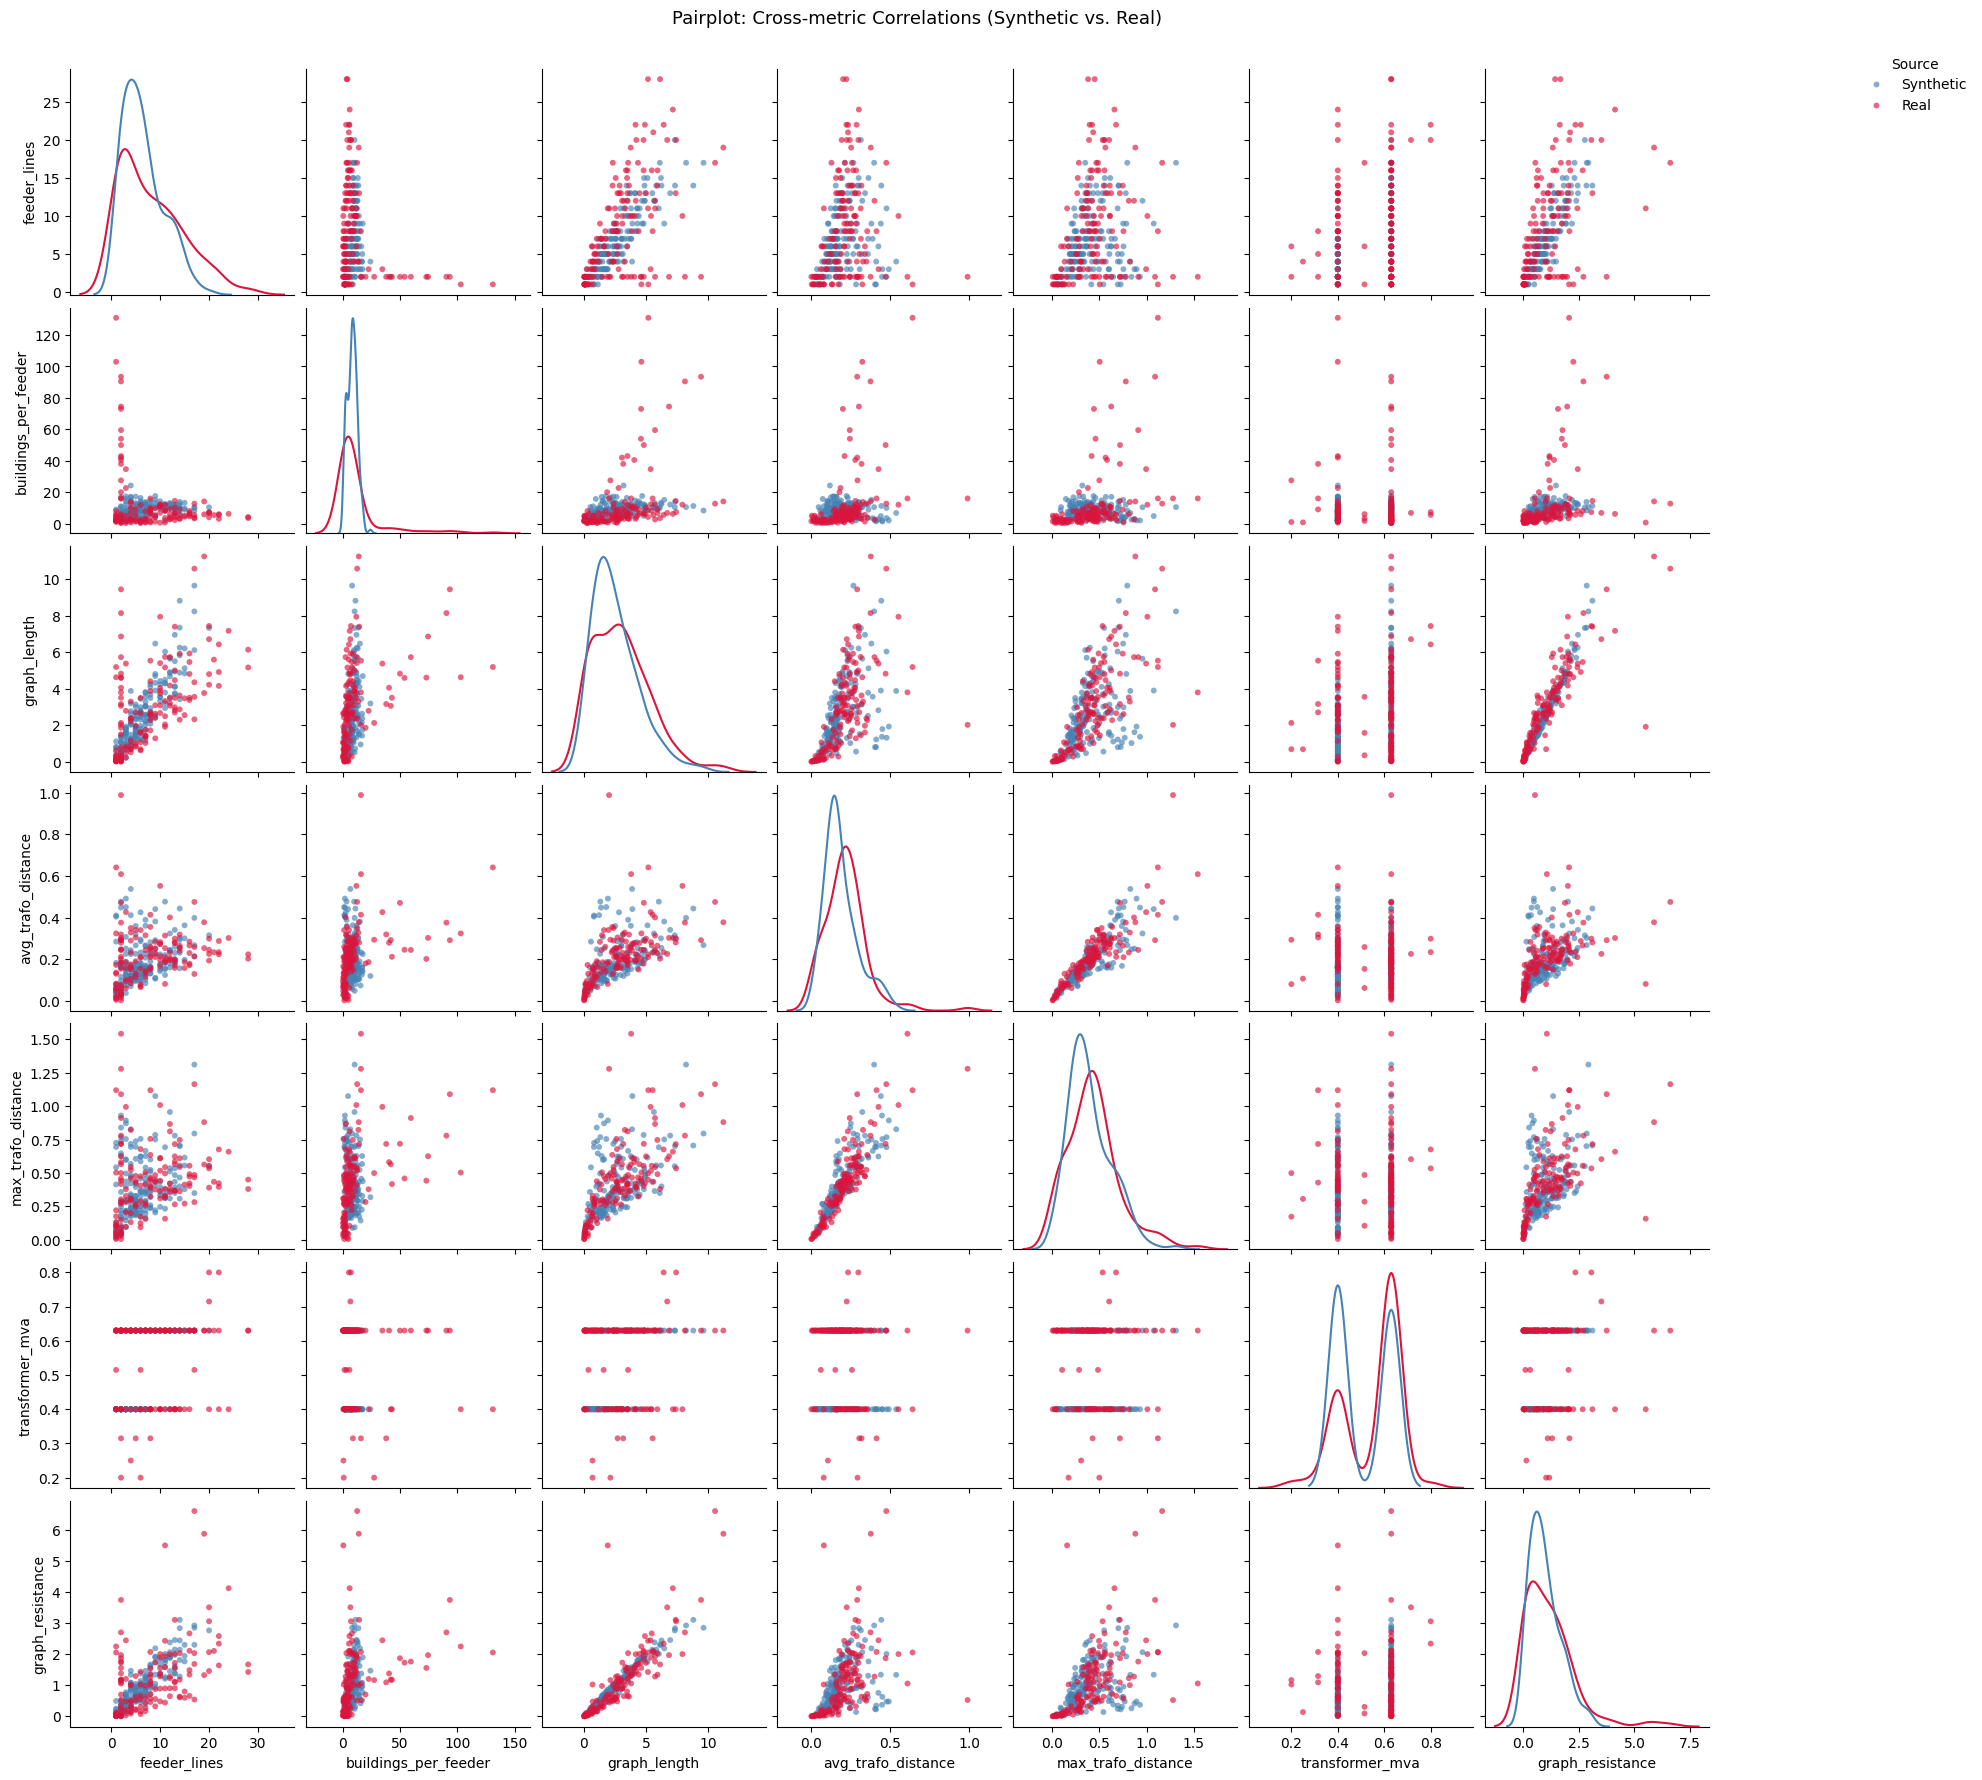

In [5]:
def plot_metric_pairplot(
    df: pd.DataFrame,
    metric_cols: list[str],
    *,
    hue_col: str = 'source',
    palette: dict | None = None,
    offdiag_kind: str = 'scatter',
    show_hist_bars: bool = False,
    corner: bool = False,
    title: str = 'Pairplot: Cross-metric Correlations (Synthetic vs. Real)',
):
    """
    Plot a reusable pairplot with optional KDE-only mode and diagonal histogram bars.
    """
    plot_data = df[metric_cols + [hue_col]].dropna()
    if plot_data.empty:
        raise ValueError('No data available for pairplot after dropping missing values.')

    if show_hist_bars:
        g = sns.PairGrid(
            plot_data,
            vars=metric_cols,
            hue=hue_col,
            palette=palette,
            corner=corner,
        )
        if offdiag_kind == 'kde':
            g.map_upper(sns.kdeplot, fill=False, levels=5, linewidths=1)
            if not corner:
                g.map_lower(sns.kdeplot, fill=False, levels=5, linewidths=1)
        else:
            g.map_upper(sns.scatterplot, alpha=0.65, s=18, linewidth=0)
            if not corner:
                g.map_lower(sns.scatterplot, alpha=0.65, s=18, linewidth=0)

        g.map_diag(
            sns.histplot,
            stat='density',
            element='bars',
            alpha=0.30,
            common_norm=False,
        )
        g.map_diag(sns.kdeplot, fill=False, linewidth=1.6, common_norm=False)
        g.add_legend(title='Source')
    else:
        g = sns.pairplot(
            plot_data,
            hue=hue_col,
            palette=palette,
            kind=offdiag_kind,
            diag_kind='kde',
            corner=corner,
            plot_kws={'alpha': 0.65, 's': 18, 'linewidth': 0},
            diag_kws={'fill': False, 'common_norm': False},
        )

    sns.move_legend(g, 'upper left', bbox_to_anchor=(1, 1), title='Source')
    g.fig.suptitle(title, y=1.02, fontsize=13)
    plt.show()
    return g


palette = {'Synthetic': 'steelblue', 'Real': 'crimson'}
g = plot_metric_pairplot(
    df_all,
    metrics,
    palette=palette,
    offdiag_kind='scatter',
    show_hist_bars=False,
    title='Pairplot: Cross-metric Correlations (Synthetic vs. Real)',
)

### 4d.1 Diagonal KDE View (Focused per Metric)

This view shows only the **diagonal-style univariate distributions** for each metric (no cross-metric relation panels).
Enable `show_hist_bars=True` to overlay histogram bars on a **count scale** so bars remain readable even for broad metrics.

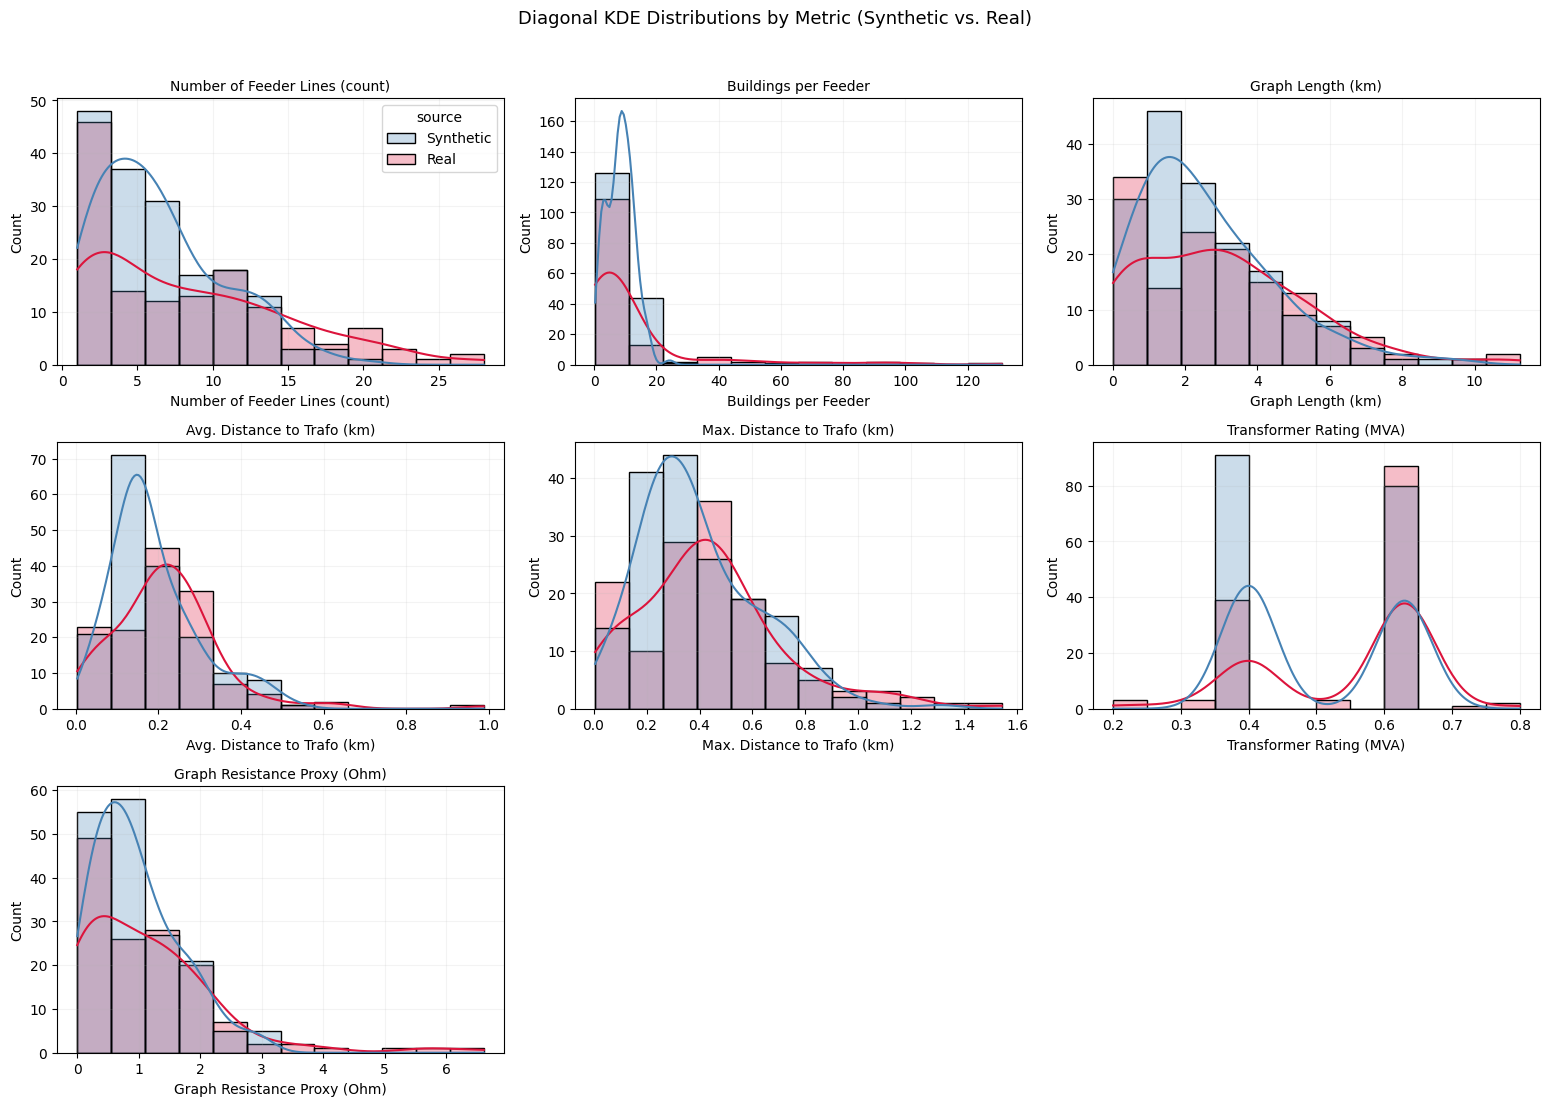

In [6]:
_ = plot_metric_kde_diagonal(
    df_all,
    metrics,
    labels=labels,
    palette=palette,
    show_hist_bars=True,
    bins=12,
    n_cols=3,
    title='Diagonal KDE Distributions by Metric (Synthetic vs. Real)',
)

### 4e. Wasserstein-Distanz (Earth Mover's Distance)

Die Wasserstein-Distanz misst, wie viel "Masse" zwischen den Verteilungen verschoben werden muss. Kleine Werte bedeuten, dass synthetische und reale Verteilungen aehnlich sind.

In diesem Notebook verwenden wir eine **normalisierte** Form je Metrik:
`normalized_wasserstein = wasserstein_distance / pooled_IQR`

Warum normalisieren wir mit der gepoolten IQR?
- Raw-Werte von Wasserstein sind in unterschiedlichen Einheiten (km, counts, MVA) und daher nicht direkt vergleichbar.
- Die IQR-Normalisierung macht den Wert dimensionslos und robuster gegen Ausreisser.
- Interpretation: `0.10` bedeutet, dass der durchschnittliche Transport-Shift etwa **10% einer robusten Streuungseinheit (IQR)** betraegt.

Praktisch heisst das:
- Die Bewertung ist streng fuer den Kern der Verteilung (mittlere 50%).
- Bei langen Tails oder Multimodalitaet immer zusammen mit den Verteilungsplots interpretieren.

Wir berechnen pro Metrik:
- `wasserstein_distance`: Distanz in den Originaleinheiten der Metrik
- `normalized_wasserstein`: Distanz relativ zur gepoolten IQR (robuste, dimensionslose Vergleichbarkeit)
- `quality`: qualitative Einordnung (`excellent`, `good`, `acceptable`, `poor`)

In [7]:
_ = show_wasserstein_summary(df_all, metrics)

,metric,synthetic_n,real_n,wasserstein_distance,normalized_wasserstein,quality
0,max_trafo_distance,171,138,0.0577,0.1910,good
1,graph_length,171,138,0.5668,0.2077,good
2,transformer_mva,171,138,0.0538,0.2340,good
3,graph_resistance,171,138,0.2745,0.2528,acceptable
4,avg_trafo_distance,171,138,0.0362,0.2697,acceptable
5,feeder_lines,171,138,2.2034,0.2754,acceptable
6,buildings_per_feeder,171,138,7.3679,0.9731,poor


### 4f. Cable Type Comparison

Compare the selected cable types as weighted counts, ordered by their impedance magnitude. The helper uses the configured `PLZ` together with `REAL_GRID_DIR` and the synthetic database export.

In [8]:
_ = show_cable_type_comparison(
    PLZ,
    real_grid_dir=REAL_GRID_DIR,
)

,std_type,source,segment_count,total_length_km,impedance_ohm_per_km
0,NS-Leitungstyp_fiktiv,Real,1152.0,14.486,0.0000
1,NS-Leitungstyp_fiktiv_air,Real,3.0,0.250,0.0000
2,NYY-J 3x240SM 0.6/1kV,Real,20.0,1.041,0.1063
3,NYY-O 3x240SM 0.6/1kV,Real,44.0,0.130,0.1063
4,NYY-J 3x185SM 0.6/1kV,Real,78.0,5.075,0.1250
...,...,...,...,...,...
62,NYY 4x4,Real,6.0,0.250,4.6147
63,NYY 4x2.5,Real,7.0,0.546,7.4141
64,NYM 4x1.5,Real,1.0,0.001,12.1192
65,NYY 3x1.5,Real,4.0,0.016,12.1192


## 5. Geospatial Comparison

Visualise individual grid topologies on an **interactive OpenStreetMap** background. This goes beyond aggregate metrics and lets you inspect how a grid is *shaped* in geographic space — feeder routing, coverage area, transformer position.

**Requirements:**
- **Real grids (5a):** Set `REAL_GRID_DIR` in Section 0 to the folder containing your pandapower exports (`LV_*.json` or `LV_*.xlsx`). Geo coordinates from `net.bus['geo']` are converted automatically to WGS84 when needed.
- **Synthetic grids (5b):** Requires a running database connection (configured via pylovo's `config.yaml`).

Both sections use `pandapower.plotting.plotly.simple_plotly(net, on_map=True, map_style="open-street-map")` — no Mapbox token required.


In [95]:
import ast as _ast
import json as _json
import pyproj as _pyproj
import plotly.graph_objects as go


def _parse_geo_coords(geo_value):
    """Extract [x, y] coordinates from GeoJSON-like values (str or dict)."""
    if geo_value is None:
        return None

    obj = None
    if isinstance(geo_value, dict):
        obj = geo_value
    elif isinstance(geo_value, str):
        candidate = geo_value
        for _ in range(3):
            try:
                candidate = _json.loads(candidate)
            except Exception:
                try:
                    candidate = _ast.literal_eval(candidate)
                except Exception:
                    break
            if isinstance(candidate, dict):
                obj = candidate
                break
            if not isinstance(candidate, str):
                break
    else:
        return None

    if not isinstance(obj, dict):
        return None
    coords = obj.get("coordinates")
    if not isinstance(coords, (list, tuple)) or len(coords) < 2:
        return None
    return [coords[0], coords[1]]


def _coords_to_wgs84(x, y):
    """Return WGS84 lon/lat from either projected or already-WGS84 coordinates."""
    if abs(x) > 180 or abs(y) > 90:
        return _UTM32_TO_WGS84.transform(x, y)
    return x, y


def _convert_net_geo_to_wgs84(net, source_crs: str = "epsg:25832"):
    """
    Convert net.bus.geo and net.line.geo GeoJSON coordinates from a projected CRS to WGS84 in-place.

    Real LV nets exported from GIS tools (e.g. Forchheim data) store coordinates in
    EPSG:25832 (UTM Zone 32N). pandapower's simple_plotly reads net.bus.geo / net.line.geo
    directly and requires WGS84 lon/lat for map rendering.
    """
    transformer = _pyproj.Transformer.from_crs(source_crs, "epsg:4326", always_xy=True)

    def _convert_point(geo_str):
        if not isinstance(geo_str, str):
            return geo_str
        try:
            g = _json.loads(geo_str)
            if g.get("type") == "Point":
                lon, lat = transformer.transform(*g["coordinates"])
                return _json.dumps({"type": "Point", "coordinates": [lon, lat]})
        except Exception:
            pass
        return geo_str

    def _convert_linestring(geo_str):
        if not isinstance(geo_str, str):
            return geo_str
        try:
            g = _json.loads(geo_str)
            if g.get("type") == "LineString":
                new_coords = [list(transformer.transform(x, y)) for x, y in g["coordinates"]]
                return _json.dumps({"type": "LineString", "coordinates": new_coords})
        except Exception:
            pass
        return geo_str

    if "geo" in net.bus.columns:
        net.bus["geo"] = net.bus["geo"].apply(_convert_point)
    if "geo" in net.line.columns:
        net.line["geo"] = net.line["geo"].apply(_convert_linestring)


def _needs_projection(net) -> bool:
    """Return True if bus.geo coordinates are in a projected CRS (not WGS84 lon/lat)."""
    if "geo" not in net.bus.columns:
        return False
    sample = net.bus["geo"].dropna()
    if sample.empty:
        return False
    coords = _parse_geo_coords(sample.iloc[0])
    if coords is None:
        return False
    return abs(coords[0]) > 180 or abs(coords[1]) > 90


def _resolve_real_grid_path(file_name: str):
    """Resolve real-grid file paths for both JSON and Excel pandapower exports."""
    base = Path(REAL_GRID_DIR) / file_name
    candidates = [base]

    suffix = Path(file_name).suffix.lower()
    if suffix == ".json":
        candidates.extend([
            base.with_suffix(".xlsx"),
            base.with_suffix(".xls"),
            base.with_suffix(".xlsm"),
        ])
    elif suffix in {".xlsx", ".xls", ".xlsm"}:
        candidates.append(base.with_suffix(".json"))
    elif not suffix:
        candidates.extend([
            Path(REAL_GRID_DIR) / f"{file_name}.json",
            Path(REAL_GRID_DIR) / f"{file_name}.xlsx",
            Path(REAL_GRID_DIR) / f"{file_name}.xls",
            Path(REAL_GRID_DIR) / f"{file_name}.xlsm",
        ])

    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None


def load_real_net_for_plotting(file_name: str):
    """
    Load a real LV grid from JSON or Excel and ensure bus.geo / line.geo are in WGS84.

    Real grid exports can be pandapower JSON or Excel. Coordinates in EPSG:25832
    are auto-detected and converted in-place so map plotting works correctly.
    """
    if REAL_GRID_DIR is None:
        print("REAL_GRID_DIR is not configured. Set it in Section 0.")
        return None

    file_path = _resolve_real_grid_path(file_name)
    if file_path is None:
        print(f"File not found in {REAL_GRID_DIR}: {file_name}")
        return None

    suffix = file_path.suffix.lower()
    if suffix == ".json":
        net = pp.from_json(str(file_path))
    elif suffix in {".xlsx", ".xls", ".xlsm"}:
        net = pp.from_excel(str(file_path))
    else:
        print(f"Unsupported real-grid format: {file_path.name}")
        return None

    if _needs_projection(net):
        _convert_net_geo_to_wgs84(net, source_crs="epsg:25832")

    return net


def _net_to_map_traces(net, line_color="grey", bus_color="blue", name_prefix=""):
    """
    Convert a pandapower net to Scattermap traces (lon/lat) for map overlay.

    Uses simple_plotly with auto_draw_traces=False to get raw x/y traces, then
    converts them to Scattermap without triggering pandapower's internal iplot call.
    """
    import pandapower.plotting.plotly as _pp_plotly

    traces, _ = _pp_plotly.simple_plotly(
        net, on_map=True, map_style="open-street-map", auto_draw_traces=False
    )

    map_traces = []
    for trace in traces:
        lon = list(trace.get("x") or [])
        lat = list(trace.get("y") or [])
        if not lon or not lat:
            continue

        line_props = {}
        if "line" in trace and trace["line"] is not None:
            try:
                raw = trace["line"]._props if hasattr(trace["line"], "_props") else dict(trace["line"])
                line_props = {k: v for k, v in raw.items() if k != "dash"}
            except Exception:
                pass

        marker_props = {}
        if "marker" in trace and trace["marker"] is not None:
            try:
                marker_props = dict(trace["marker"]._props) if hasattr(trace["marker"], "_props") else dict(trace["marker"])
            except Exception:
                pass

        map_traces.append(go.Scattermap(
            lon=lon,
            lat=lat,
            mode=trace.get("mode", "markers"),
            name=f"{name_prefix}{trace.get('name', '')}",
            text=trace.get("text", ""),
            hoverinfo=trace.get("hoverinfo", "text"),
            showlegend=trace.get("showlegend", True),
            legendgroup=f"{name_prefix}{trace.get('legendgroup', '')}",
            line=line_props if line_props else None,
            marker=marker_props if marker_props else None,
        ))

    return map_traces


def _get_geo_bbox(net):
    """Return (lon_min, lat_min, lon_max, lat_max) from net.bus.geo."""
    if "geo" not in net.bus.columns:
        return None

    lons, lats = [], []
    for geo_value in net.bus["geo"].dropna():
        coords = _parse_geo_coords(geo_value)
        if coords is None:
            continue
        lon, lat = _coords_to_wgs84(coords[0], coords[1])
        lons.append(lon)
        lats.append(lat)

    if not lons:
        return None
    return min(lons), min(lats), max(lons), max(lats)


def _bboxes_intersect(a, b):
    """Check if two (lon_min, lat_min, lon_max, lat_max) bounding boxes overlap."""
    return not (a[2] < b[0] or b[2] < a[0] or a[3] < b[1] or b[3] < a[1])


# Module-level transformer for EPSG:25832 -> WGS84 (re-used by helpers to avoid per-call overhead)
_UTM32_TO_WGS84 = _pyproj.Transformer.from_crs("epsg:25832", "epsg:4326", always_xy=True)


def _bbox_from_geo_values(geo_values):
    """Compute WGS84 bbox from an iterable of GeoJSON-like values."""
    lons, lats = [], []
    for geo_value in geo_values:
        coords = _parse_geo_coords(geo_value)
        if coords is None:
            continue
        lon, lat = _coords_to_wgs84(coords[0], coords[1])
        lons.append(lon)
        lats.append(lat)

    if not lons:
        return None
    return min(lons), min(lats), max(lons), max(lats)


def _get_bbox_fast(file_path: str):
    """
    Return (lon_min, lat_min, lon_max, lat_max) from a real-grid file without
    loading a full pandapower network when possible.

    Supports both pandapower JSON and Excel exports. Coordinates in EPSG:25832
    are auto-converted to WGS84.
    """
    try:
        suffix = Path(file_path).suffix.lower()

        if suffix in {".xlsx", ".xls", ".xlsm"}:
            bus_df = pd.read_excel(file_path, sheet_name="bus")
            if "geo" not in bus_df.columns:
                return None
            return _bbox_from_geo_values(bus_df["geo"].dropna())

        with open(file_path) as _f:
            data = _json.load(_f)

        bus_raw = data["_object"]["bus"]["_object"]
        bus_obj = _json.loads(bus_raw) if isinstance(bus_raw, str) else bus_raw
        cols = bus_obj["columns"]
        rows = bus_obj["data"]
        geo_idx = cols.index("geo")
        geo_values = [row[geo_idx] for row in rows]
        return _bbox_from_geo_values(geo_values)
    except Exception:
        pass
    return None

### 5a. Real Grid Map

Select a real grid by name. The network topology (buses and lines) is drawn on an OpenStreetMap background. Bus markers show transformer and consumer buses; line traces show the cable routing.

> Requires `REAL_GRID_DIR` to be set in Section 0.


In [96]:
if not df_real.empty and 'file_name' in df_real.columns:
    real_grid_map = dict(
        df_real[['grid_name', 'file_name']].dropna().itertuples(index=False, name=None)
    )

    def plot_real_grid(grid_name):
        net = load_real_net_for_plotting(real_grid_map[grid_name])
        if net is None or net.bus["geo"].dropna().empty:
            print("No geographic data found in this grid.")
            return

        traces = _net_to_map_traces(net)
        bbox = _get_geo_bbox(net)
        center_lon = (bbox[0] + bbox[2]) / 2 if bbox else 0
        center_lat = (bbox[1] + bbox[3]) / 2 if bbox else 0

        fig = go.Figure(data=traces)
        fig.update_layout(
            title_text=f"Real Grid: {grid_name}",
            height=640,
            showlegend=True,
            margin=dict(l=5, r=5, b=5, t=40),
            map=dict(style="open-street-map", zoom=14, center=dict(lon=center_lon, lat=center_lat)),
        )
        fig.show()

    interact(
        plot_real_grid,
        grid_name=widgets.Dropdown(
            options=list(real_grid_map.keys()),
            description="Grid:",
            layout=widgets.Layout(width='300px'),
        ),
    )
else:
    print("No real grid data available. Ensure real_grid_metrics.csv is loaded and REAL_GRID_DIR is set.")


interactive(children=(Dropdown(description='Grid:', layout=Layout(width='300px'), options=('LV_028', 'LV_030',…

### 5b. Synthetic Grid Map with Real Grid Overlay

Enter the `plz`, `kcid`, and `bcid` of any generated grid. The synthetic network is plotted in **blue/grey/green** (buses / lines / transformer). Any real grids whose geographic bounding box **intersects** the synthetic grid's extent are automatically overlaid in **red** on the same map.

> Requires a database connection. If `REAL_GRID_DIR` is also set, overlapping real grids are loaded and overlaid automatically.


In [97]:
# -- 5b State ---------------------------------------------------------------
_5b_state = {}  # persistent between the two widget steps

# -- Widgets -----------------------------------------------------------------
_plz_w   = widgets.IntText(value=91301, description="PLZ:",
                            layout=widgets.Layout(width="200px"))
_kcid_w  = widgets.IntText(value=0,     description="KCID:",
                            layout=widgets.Layout(width="200px"))
_bcid_w  = widgets.IntText(value=0,     description="BCID:",
                            layout=widgets.Layout(width="200px"))

_find_btn  = widgets.Button(
    description="1. Find Intersecting Grids",
    button_style="primary",
    layout=widgets.Layout(width="240px"),
)
_step1_out = widgets.Output()

_real_dd  = widgets.Dropdown(
    description="Real grid:", options=[],
    layout=widgets.Layout(width="340px"),
)
_plot_btn = widgets.Button(
    description="2. Plot Overlay",
    button_style="success",
    layout=widgets.Layout(width="160px"),
)
_step2_out = widgets.Output()
_step2_box = widgets.VBox([widgets.HBox([_real_dd, _plot_btn]), _step2_out])
_step2_box.layout.display = "none"  # hidden until step 1 succeeds


# -- Step 1: load synthetic grid and scan real grids for bbox overlap --------
def _5b_find_click(_):
    _step1_out.clear_output()
    _step2_box.layout.display = "none"
    _step2_out.clear_output()
    with _step1_out:
        plz, kcid, bcid = _plz_w.value, _kcid_w.value, _bcid_w.value
        print(f"Loading synthetic grid  PLZ={plz}  KCID={kcid}  BCID={bcid} ...")
        try:
            with DatabaseClient() as dbc:
                net_synth = dbc.read_net_db(int(plz), int(kcid), int(bcid))
        except Exception as exc:
            print(f"Could not load synthetic grid: {exc}")
            return

        synth_bbox = _get_geo_bbox(net_synth)
        _5b_state.update(net_synth=net_synth, synth_bbox=synth_bbox,
                         plz=plz, kcid=kcid, bcid=bcid)

        if (
            REAL_GRID_DIR is None
            or df_real.empty
            or "file_name" not in df_real.columns
            or synth_bbox is None
        ):
            print("REAL_GRID_DIR not configured or no real grid data - showing synthetic only.")
            _5b_plot(selected_real=None)
            return

        print("Scanning real grids for bounding-box intersection ...")
        intersecting = []
        for _, row in df_real[["grid_name", "file_name"]].dropna().iterrows():
            fp = _resolve_real_grid_path(str(row["file_name"]))
            if fp is None:
                continue
            real_bbox = _get_bbox_fast(str(fp))
            if real_bbox and _bboxes_intersect(synth_bbox, real_bbox):
                intersecting.append((row["grid_name"], row["file_name"]))

        if not intersecting:
            print("No intersecting real grids found - showing synthetic only.")
            _5b_plot(selected_real=None)
            return

        _5b_state["fname_lookup"] = {name: fname for name, fname in intersecting}
        _real_dd.options = [name for name, _ in intersecting]

        n = len(intersecting)
        print(f"Found {n} intersecting real grid(s).  "
              f"Select one and click '2. Plot Overlay'.")
    _step2_box.layout.display = ""


_find_btn.on_click(_5b_find_click)


# -- Step 2: render synthetic + one selected real grid -----------------------
def _5b_plot(selected_real):
    net_synth  = _5b_state.get("net_synth")
    synth_bbox = _5b_state.get("synth_bbox")
    plz  = _5b_state.get("plz",  "?")
    kcid = _5b_state.get("kcid", "?")
    bcid = _5b_state.get("bcid", "?")

    synth_traces = _net_to_map_traces(net_synth, name_prefix="Synthetic: ")
    all_traces   = list(synth_traces)

    if selected_real is not None:
        fname    = _5b_state.get("fname_lookup", {}).get(selected_real, selected_real)
        net_real = load_real_net_for_plotting(fname)
        if net_real is not None:
            real_traces = _net_to_map_traces(
                net_real, name_prefix=f"Real {selected_real}: "
            )
            for t in real_traces:
                t.update(
                    line=dict(color="crimson"),
                    marker=dict(color="crimson"),
                )
            all_traces.extend(real_traces)

    if not all_traces:
        print("No plottable geo data found.")
        return

    center_lon = ((synth_bbox[0] + synth_bbox[2]) / 2) if synth_bbox else 0
    center_lat = ((synth_bbox[1] + synth_bbox[3]) / 2) if synth_bbox else 0

    fig = go.Figure(data=all_traces)
    fig.update_layout(
        title_text=f"Synthetic Grid - PLZ {plz}, KCID {kcid}, BCID {bcid}",
        height=660,
        showlegend=True,
        margin=dict(l=5, r=5, b=5, t=40),
        map=dict(
            style="open-street-map",
            zoom=14,
            center=dict(lon=center_lon, lat=center_lat),
        ),
    )
    fig.show()


def _5b_plot_click(_):
    with _step2_out:
        _step2_out.clear_output()
        selected_real = _real_dd.value
        if selected_real:
            print(f"Loading real grid '{selected_real}' ...")
            _5b_plot(selected_real)


_plot_btn.on_click(_5b_plot_click)

# -- Layout ------------------------------------------------------------------
display(
    widgets.VBox([
        widgets.HTML(
            "<b>Synthetic Grid - Real Grid Overlay</b><br>"
            "<small><b>Step 1:</b> Enter the grid coordinates and click "
            "<i>Find Intersecting Grids</i>.<br>"
            "<b>Step 2:</b> Pick one matching real grid and click "
            "<i>Plot Overlay</i>.</small>"
        ),
        widgets.HBox([_plz_w, _kcid_w, _bcid_w]),
        _find_btn,
        _step1_out,
        _step2_box,
    ])
)


### 5c. Geographic Coverage Overview

Static overview map showing where **synthetic grids** (transformer locations, left) and **real grids** (grid centroids, right) are located.  Both datasets cover the same area around Forchheim, Bavaria — this plot confirms their geographic overlap before deeper comparisons.

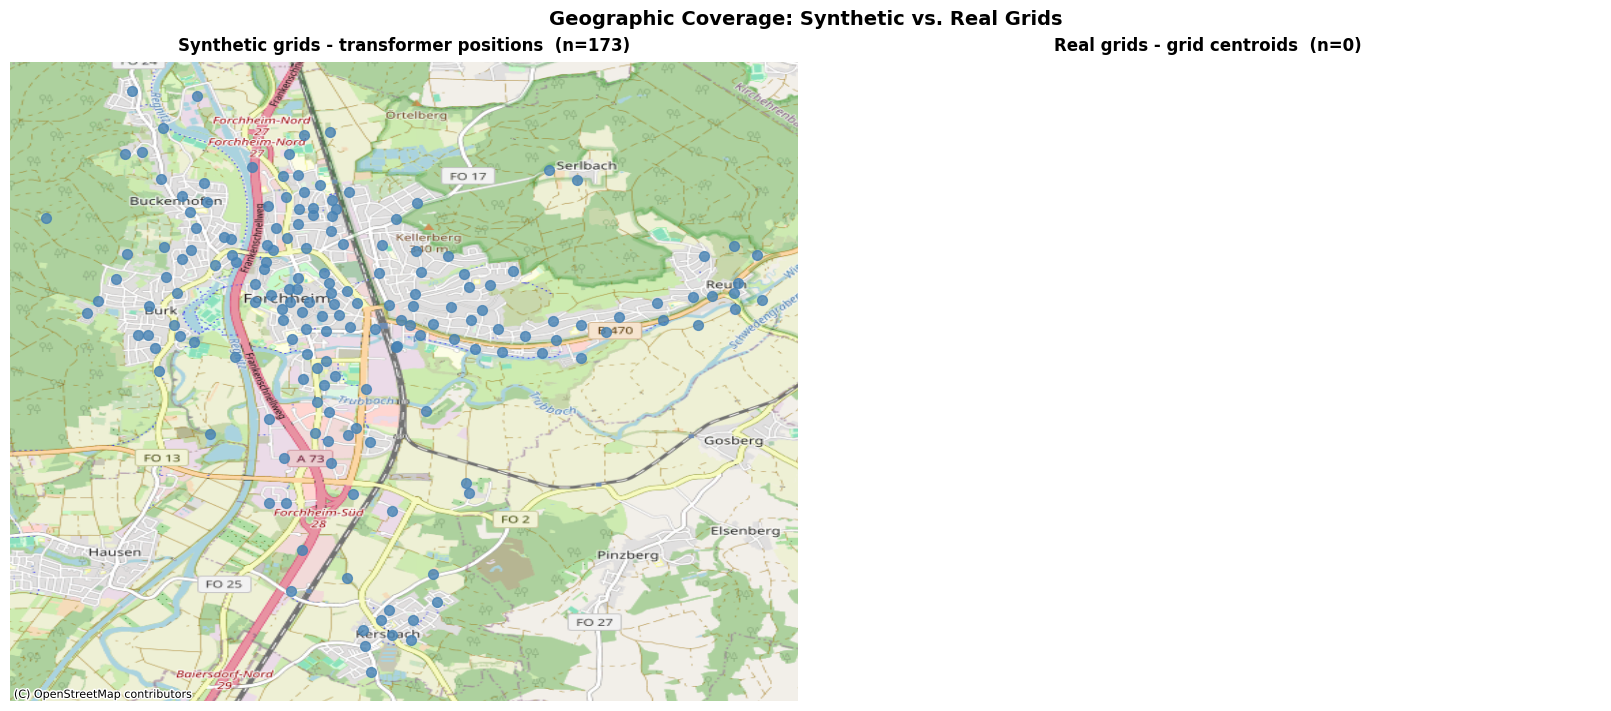

In [98]:
import contextily as cx

# -- Synthetic grid positions - transformer coordinates from DB ---------------
_synth_ids = df_synth["grid_result_id"].dropna().astype(int).unique().tolist()
with DatabaseClient() as dbc:
    _q_synth = f"""
        SELECT grid_result_id,
               ST_X(ST_Transform(geom, 4326)) AS lon,
               ST_Y(ST_Transform(geom, 4326)) AS lat
        FROM transformer_positions
        WHERE grid_result_id = ANY(ARRAY{_synth_ids})
    """
    df_synth_geo = pd.read_sql(_q_synth, dbc.sqla_engine)

# -- Real grid positions - centroids from real-grid files ---------------------
_real_centroids = []
if REAL_GRID_DIR is not None and not df_real.empty and "file_name" in df_real.columns:
    for _, _row in df_real[["grid_name", "file_name"]].dropna().iterrows():
        _fp = _resolve_real_grid_path(str(_row["file_name"]))
        if _fp is None:
            continue
        _bb = _get_bbox_fast(str(_fp))
        if _bb:
            _real_centroids.append({
                "grid_name": _row["grid_name"],
                "lon": (_bb[0] + _bb[2]) / 2,
                "lat": (_bb[1] + _bb[3]) / 2,
            })
df_real_geo = pd.DataFrame(_real_centroids)

# -- WGS84 -> Web Mercator (EPSG:3857) for contextily -------------------------
_to_web = _pyproj.Transformer.from_crs("epsg:4326", "epsg:3857", always_xy=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

# Left - synthetic transformer positions
ax = axes[0]
if not df_synth_geo.empty:
    _sx, _sy = _to_web.transform(
        df_synth_geo["lon"].values, df_synth_geo["lat"].values
    )
    ax.scatter(_sx, _sy, c="steelblue", s=50, alpha=0.8, zorder=3)
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(
    f"Synthetic grids - transformer positions  (n={len(df_synth_geo)})",
    fontsize=12, fontweight="bold", pad=8,
)
ax.set_axis_off()

# Right - real grid centroids
ax = axes[1]
if not df_real_geo.empty:
    _rx, _ry = _to_web.transform(
        df_real_geo["lon"].values, df_real_geo["lat"].values
    )
    ax.scatter(_rx, _ry, c="crimson", s=50, alpha=0.8, zorder=3)
    cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik)
ax.set_title(
    f"Real grids - grid centroids  (n={len(df_real_geo)})",
    fontsize=12, fontweight="bold", pad=8,
)
ax.set_axis_off()

fig.suptitle(
    "Geographic Coverage: Synthetic vs. Real Grids",
    fontsize=14, fontweight="bold",
)
plt.show()


## 6. Export Synthetic Grids to Excel

Export one specific synthetic grid — or the entire set stored in the database — to `.xlsx` files for inspection in Excel.  Each file is named `grid_{plz}_{kcid}_{bcid}.xlsx` and contains one sheet per pandapower element table (`bus`, `line`, `load`, `trafo`, …) exactly as produced by `pp.to_excel`.

| Argument | Effect |
|---|---|
| `output_dir` | Destination folder (created automatically if it does not exist) |
| `plz`, `kcid`, `bcid` | All three provided → exports that single grid |
| *(all omitted)* | Exports every grid for the current `VERSION_ID` |

> **Requires** a database connection.  Configure the connection via pylovo's `config.yaml` before running.
